In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [3]:
models = [
    "bert-base-multilingual-cased",
    "muril-base-cased",
    "xlm-roberta-base"
]
states  = ["pretrained", "finetuned"]
emotions = ["anger", "disgust", "joy", "sadness"]

results = {}
for model in models:
    for state in states:
        path = f"/Users/harshaggarwal/Projects_4/hinemo_project/models/probing_results/{model}/emotion_probing_{state}.json"
        with open(path) as f:
            results[(model, state)] = json.load(f)

print("Loaded combinations:")
for key in results:
    r = results[key]
    print(f"  {key[0]:<35} {key[1]:<12} ELDS={r['ELDS']:.3f}")

Loaded combinations:
  bert-base-multilingual-cased        pretrained   ELDS=0.667
  bert-base-multilingual-cased        finetuned    ELDS=0.000
  muril-base-cased                    pretrained   ELDS=0.000
  muril-base-cased                    finetuned    ELDS=1.167
  xlm-roberta-base                    pretrained   ELDS=0.000
  xlm-roberta-base                    finetuned    ELDS=0.000


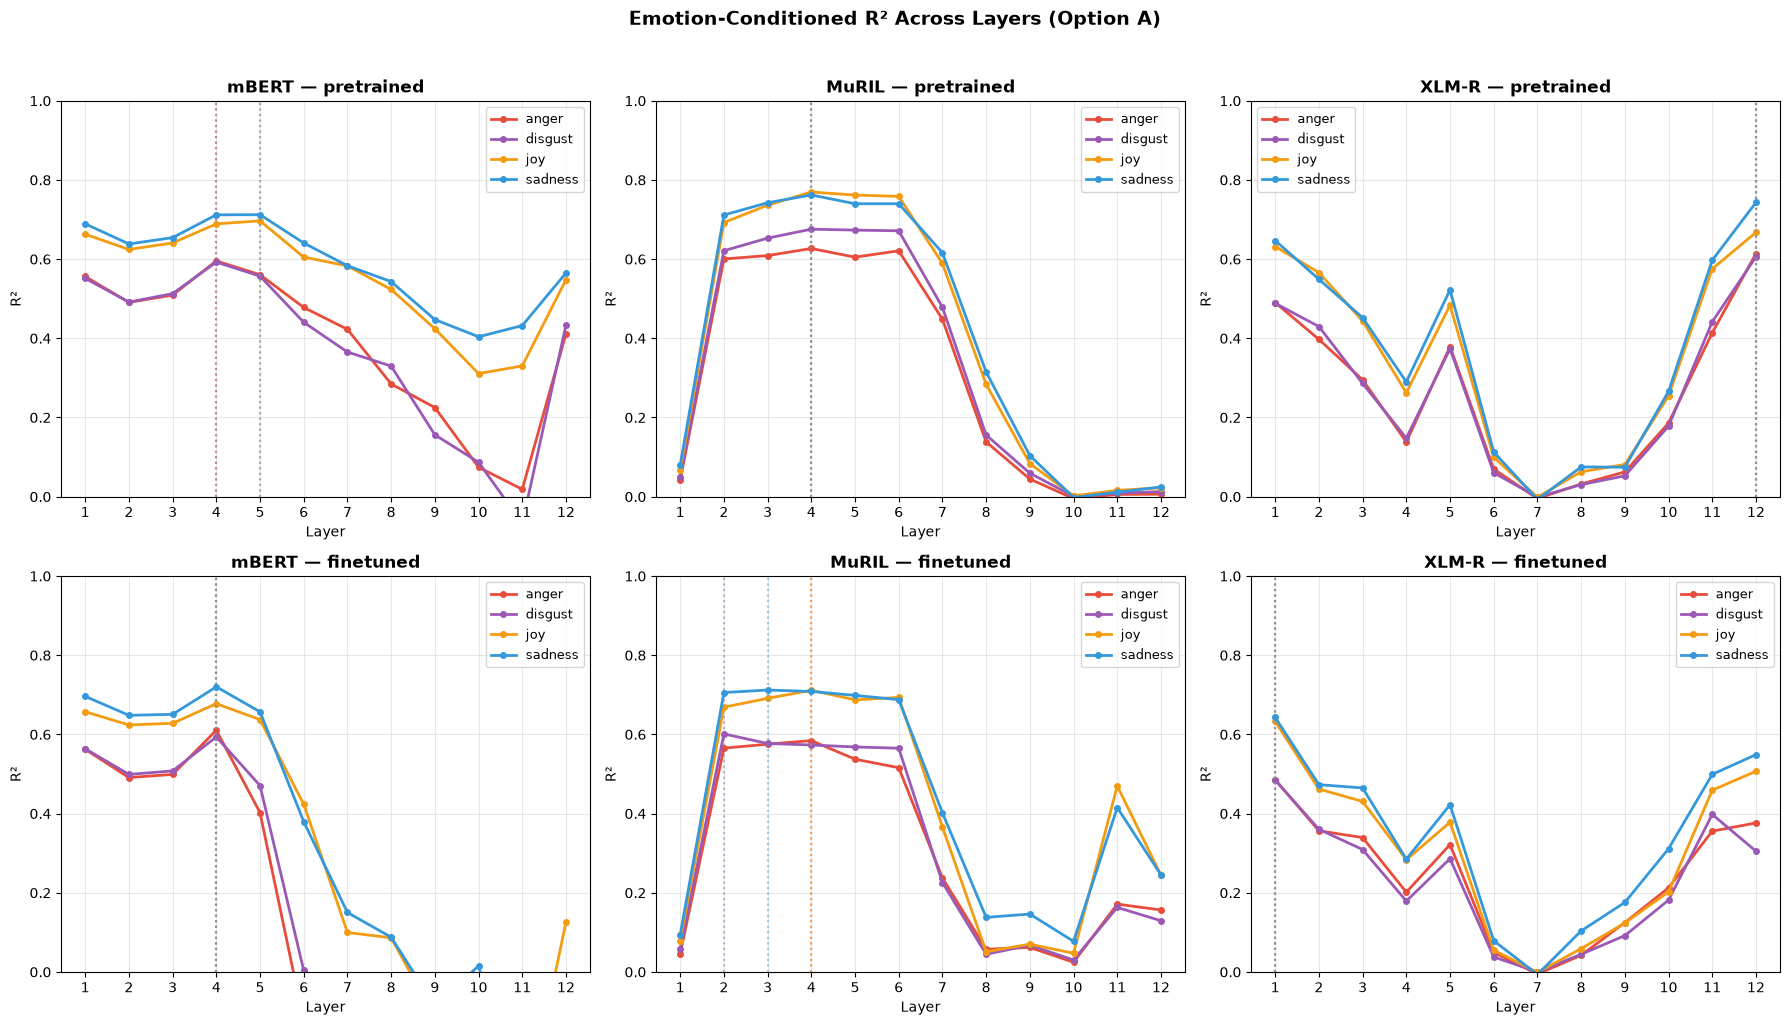

Saved.


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

emotion_colors = {
    "anger"  : "#e74c3c",
    "disgust": "#9b59b6",
    "joy"    : "#f39c12",
    "sadness": "#3498db"
}

model_short = {
    "bert-base-multilingual-cased": "mBERT",
    "muril-base-cased"            : "MuRIL",
    "xlm-roberta-base"            : "XLM-R"
}

layers = list(range(1, 13))

for col, model in enumerate(models):
    for row, state in enumerate(states):
        ax  = axes[row, col]
        r   = results[(model, state)]

        for emotion in emotions:
            r2_curve = r["r2_per_emotion"][emotion]
            lsl      = r["lsl_per_emotion"][emotion]
            ax.plot(layers, r2_curve,
                    label=emotion,
                    color=emotion_colors[emotion],
                    linewidth=2,
                    marker="o",
                    markersize=4)
            # mark the LSL with a vertical dotted line
            ax.axvline(x=lsl,
                       color=emotion_colors[emotion],
                       linestyle=":",
                       alpha=0.5)

        ax.set_title(f"{model_short[model]} — {state}", fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("R²")
        ax.set_xticks(layers)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Emotion-Conditioned R² Across Layers (Option A)", 
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()

os.makedirs("models/figures", exist_ok=True)
plt.savefig("models/figures/optionA_per_model_per_state.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

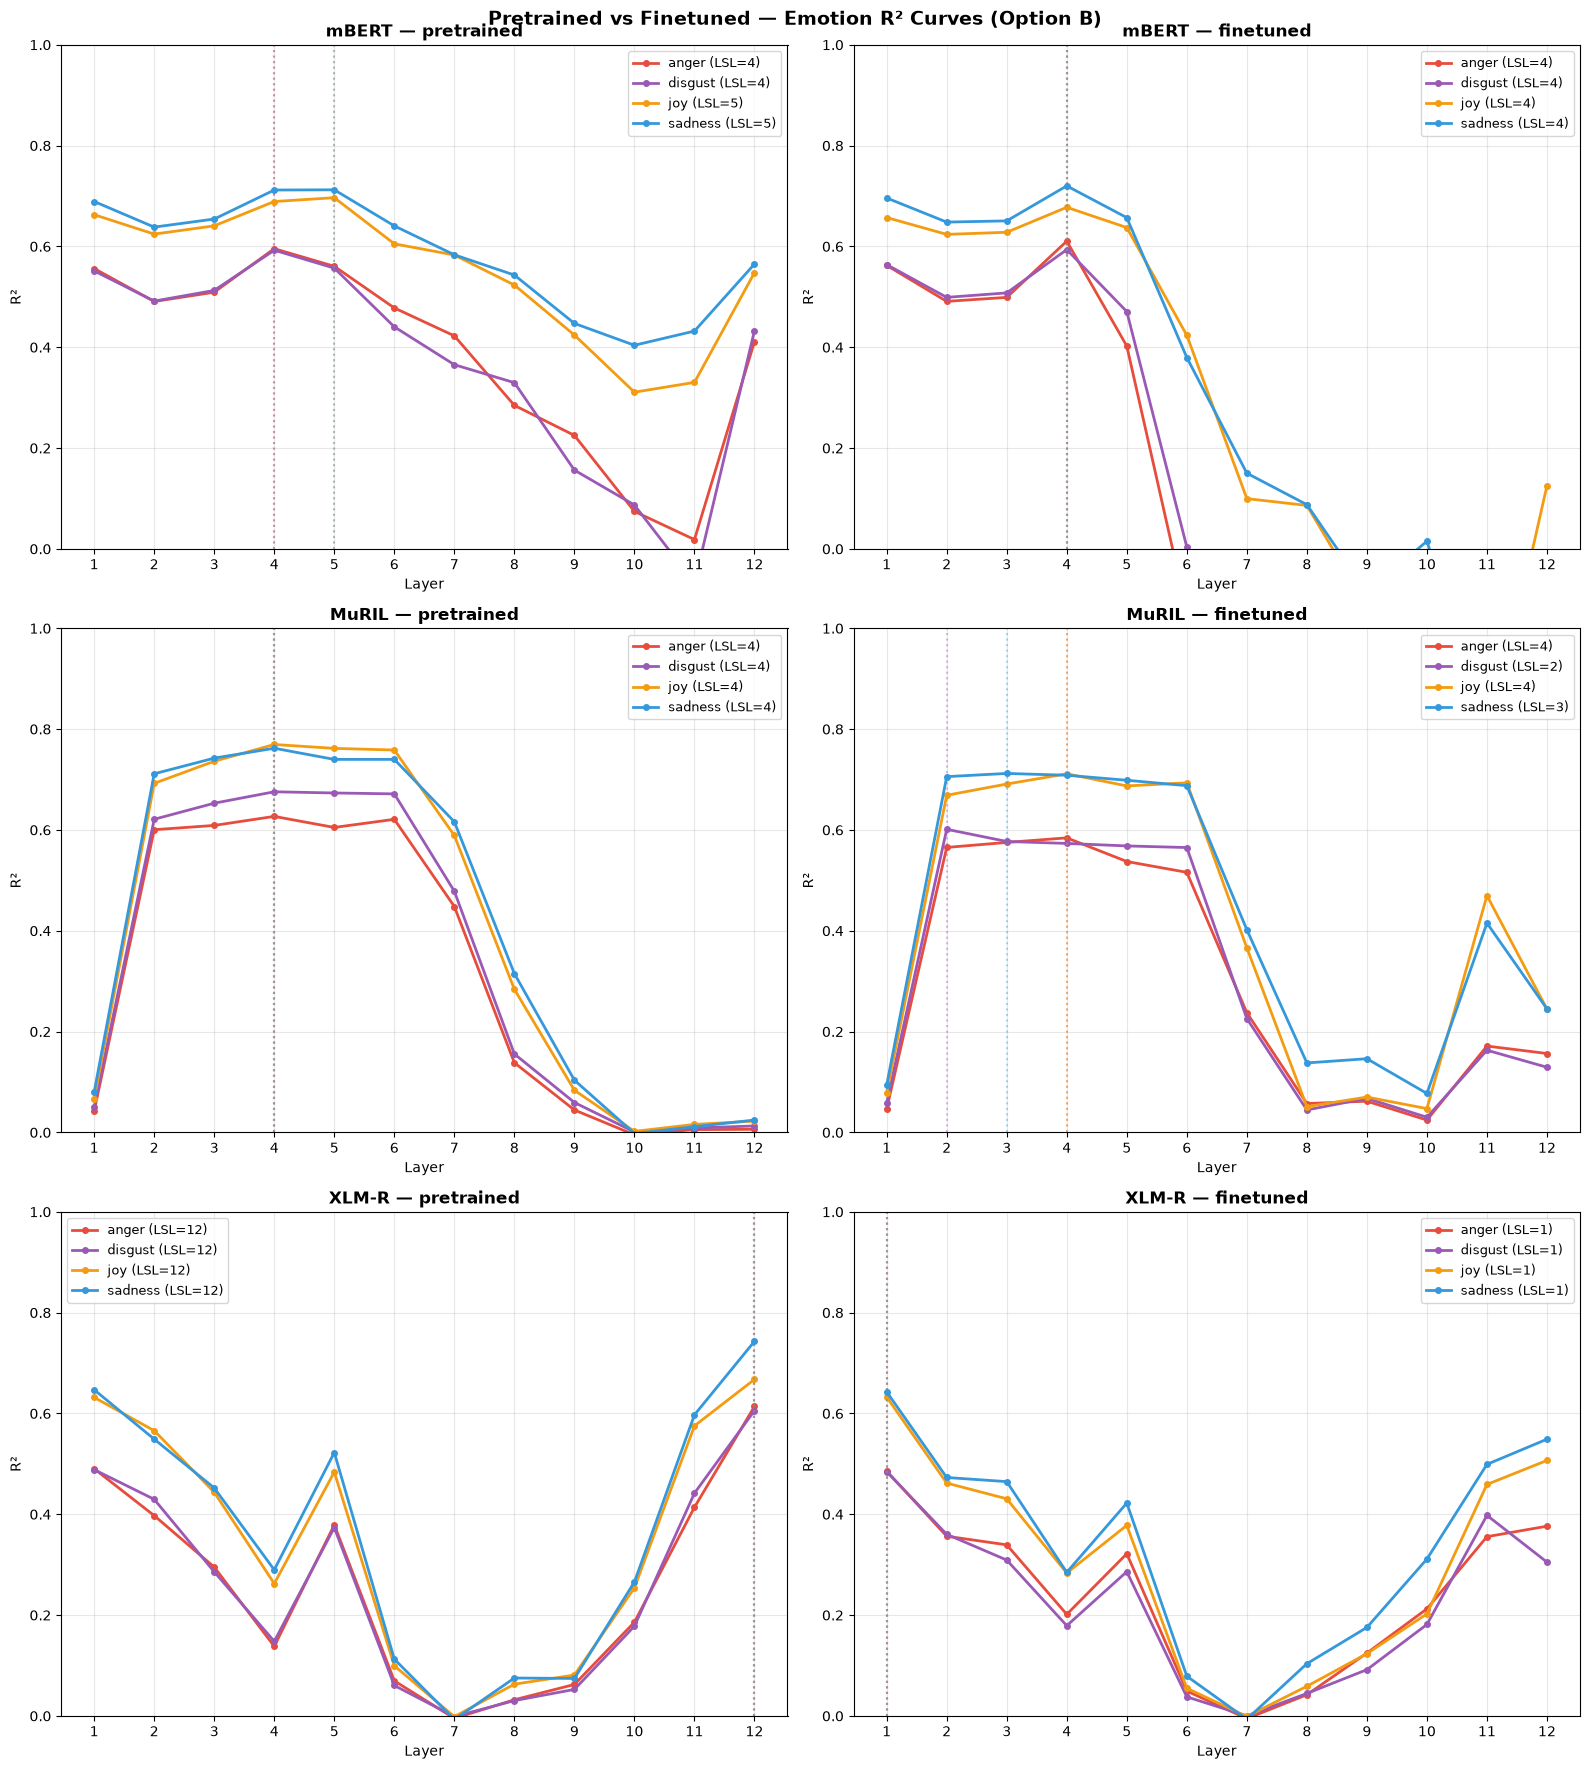

Saved.


In [6]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))

for row, model in enumerate(models):
    for col, state in enumerate(states):
        ax = axes[row, col]
        r  = results[(model, state)]

        for emotion in emotions:
            r2_curve = r["r2_per_emotion"][emotion]
            lsl      = r["lsl_per_emotion"][emotion]
            ax.plot(layers, r2_curve,
                    label=f"{emotion} (LSL={lsl})",
                    color=emotion_colors[emotion],
                    linewidth=2,
                    marker="o",
                    markersize=4)
            ax.axvline(x=lsl,
                       color=emotion_colors[emotion],
                       linestyle=":",
                       alpha=0.4)

        ax.set_title(f"{model_short[model]} — {state}", 
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("R²")
        ax.set_xticks(layers)
        ax.set_ylim(0, 1)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.suptitle("Pretrained vs Finetuned — Emotion R² Curves (Option B)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("models/figures/optionB_pretrained_vs_finetuned.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

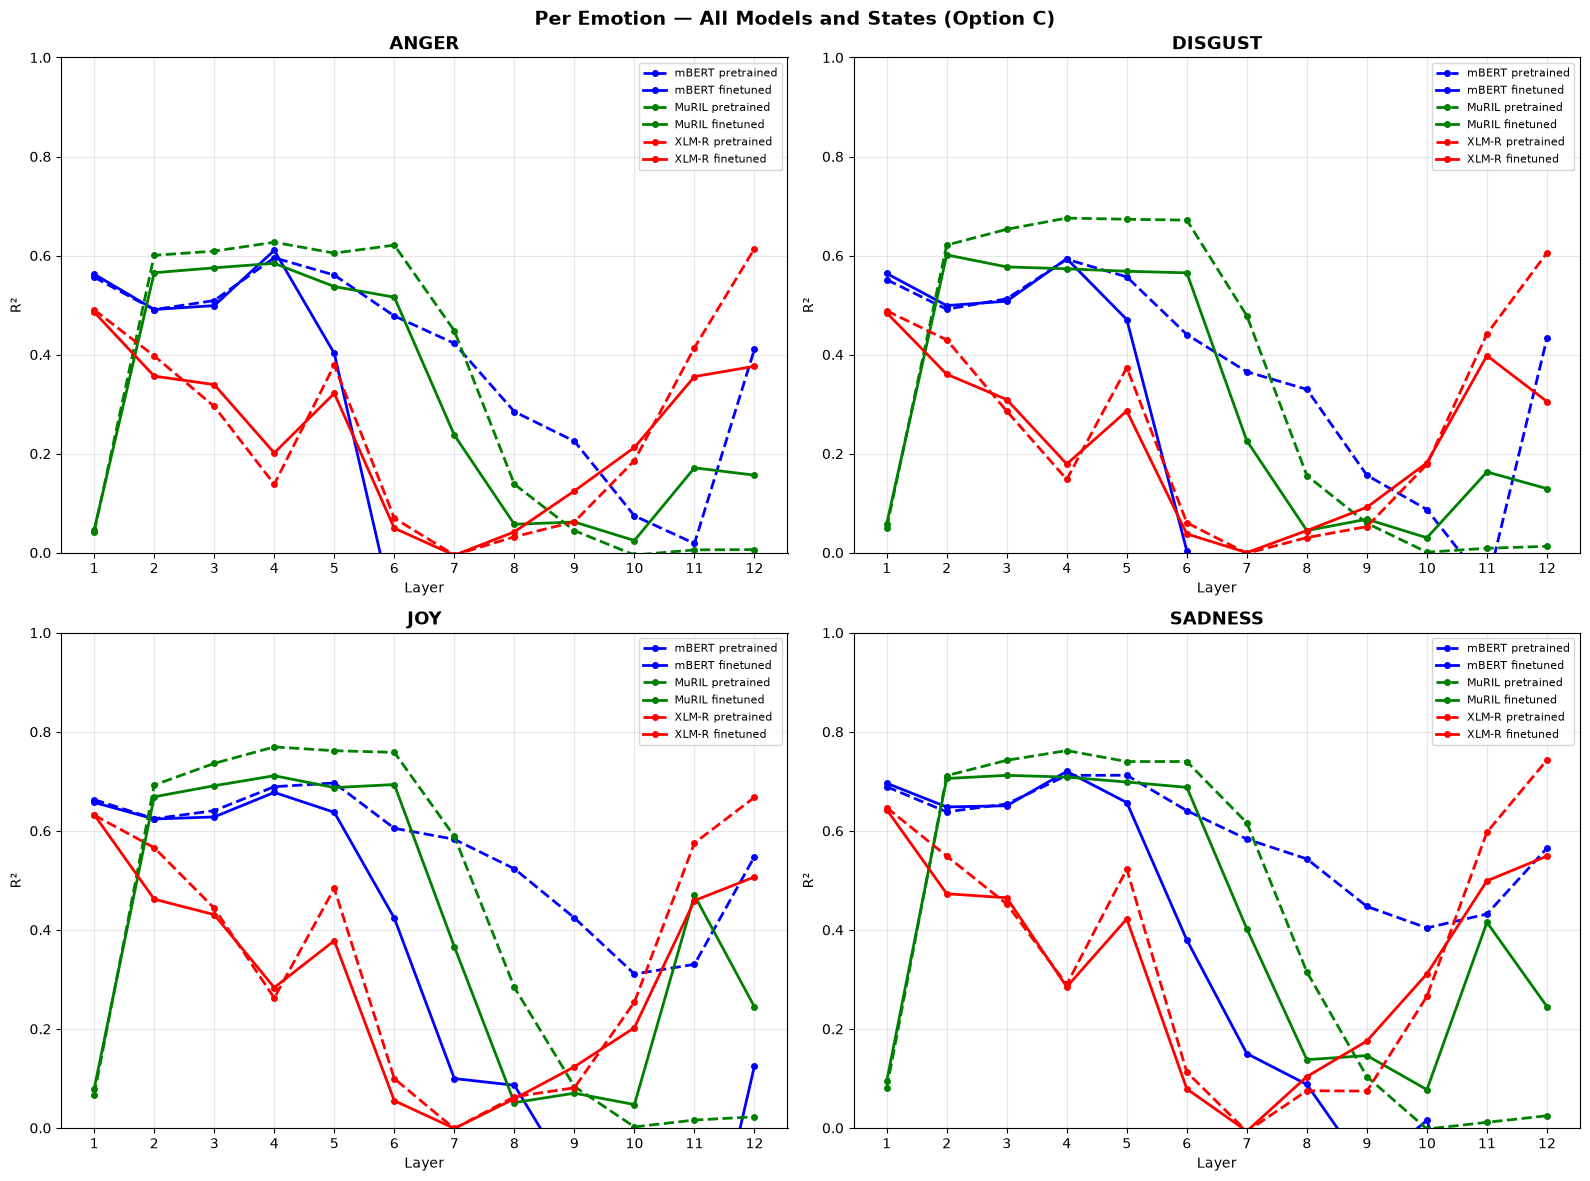

Saved.


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

model_state_styles = {
    ("bert-base-multilingual-cased", "pretrained") : ("blue",   "--", "mBERT pretrained"),
    ("bert-base-multilingual-cased", "finetuned")  : ("blue",   "-",  "mBERT finetuned"),
    ("muril-base-cased",             "pretrained") : ("green",  "--", "MuRIL pretrained"),
    ("muril-base-cased",             "finetuned")  : ("green",  "-",  "MuRIL finetuned"),
    ("xlm-roberta-base",             "pretrained") : ("red",    "--", "XLM-R pretrained"),
    ("xlm-roberta-base",             "finetuned")  : ("red",    "-",  "XLM-R finetuned"),
}

for idx, emotion in enumerate(emotions):
    ax = axes[idx]

    for (model, state), (color, linestyle, label) in model_state_styles.items():
        r2_curve = results[(model, state)]["r2_per_emotion"][emotion]
        ax.plot(layers, r2_curve,
                label=label,
                color=color,
                linestyle=linestyle,
                linewidth=2,
                marker="o",
                markersize=4)

    ax.set_title(f"{emotion.upper()}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("R²")
    ax.set_xticks(layers)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Per Emotion — All Models and States (Option C)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("models/figures/optionC_per_emotion.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

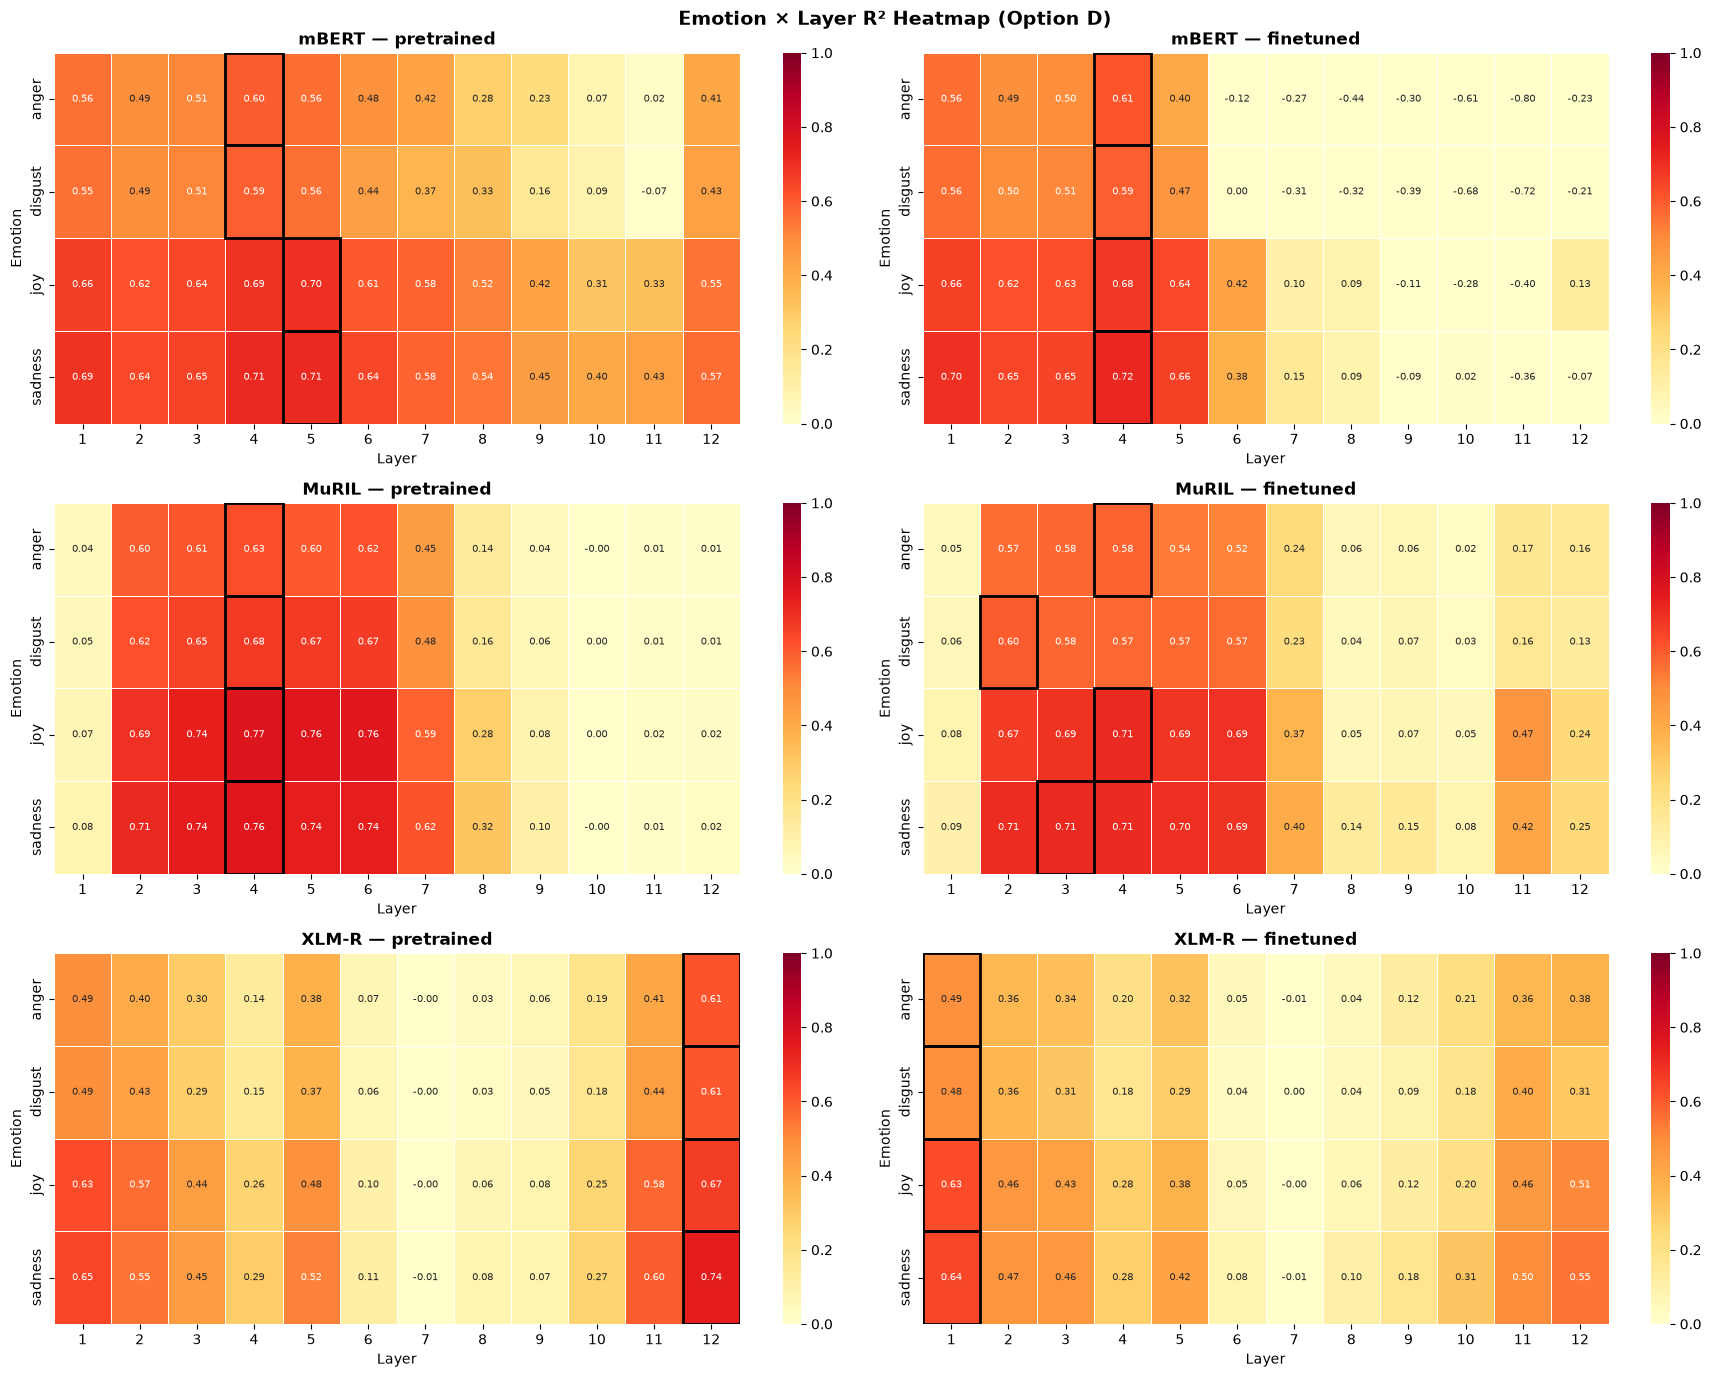

Saved.


In [8]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

for row, model in enumerate(models):
    for col, state in enumerate(states):
        ax = axes[row, col]
        r  = results[(model, state)]

        # Build matrix: rows=emotions, cols=layers
        matrix = np.array([
            r["r2_per_emotion"][emotion] for emotion in emotions
        ])  # shape: (4, 12)

        sns.heatmap(
            matrix,
            ax=ax,
            vmin=0,
            vmax=1,
            cmap="YlOrRd",
            xticklabels=[str(l) for l in layers],
            yticklabels=emotions,
            annot=True,
            fmt=".2f",
            annot_kws={"size": 7},
            linewidths=0.5,
            linecolor="white",
            cbar=True
        )

        # Mark LSL for each emotion with a star
        for e_idx, emotion in enumerate(emotions):
            lsl = r["lsl_per_emotion"][emotion]
            ax.add_patch(plt.Rectangle(
                (lsl-1, e_idx), 1, 1,
                fill=False,
                edgecolor="black",
                lw=2
            ))

        ax.set_title(f"{model_short[model]} — {state}",
                     fontsize=12, fontweight="bold")
        ax.set_xlabel("Layer")
        ax.set_ylabel("Emotion")

plt.suptitle("Emotion × Layer R² Heatmap (Option D)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("/Users/harshaggarwal/Projects_4/hinemo_project/models/figures/optionD_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")

In [9]:
phase7_results = {}
for model in models:
    for state in states:
        path = f"/Users/harshaggarwal/Projects_4/hinemo_project/models/probing_results/{model}/probing_{state}.json"
        with open(path) as f:
            phase7_results[(model, state)] = json.load(f)

print("Phase 7 results loaded:")
for key, r in phase7_results.items():
    print(f"  {key[0]:<35} {key[1]:<12} LSL={r['LSL']}  Peak R²={r['peak_r2']:.4f}")

Phase 7 results loaded:
  bert-base-multilingual-cased        pretrained   LSL=5  Peak R²=0.7139
  bert-base-multilingual-cased        finetuned    LSL=4  Peak R²=0.6970
  muril-base-cased                    pretrained   LSL=4  Peak R²=0.7615
  muril-base-cased                    finetuned    LSL=3  Peak R²=0.7120
  xlm-roberta-base                    pretrained   LSL=12  Peak R²=0.7005
  xlm-roberta-base                    finetuned    LSL=1  Peak R²=0.6525


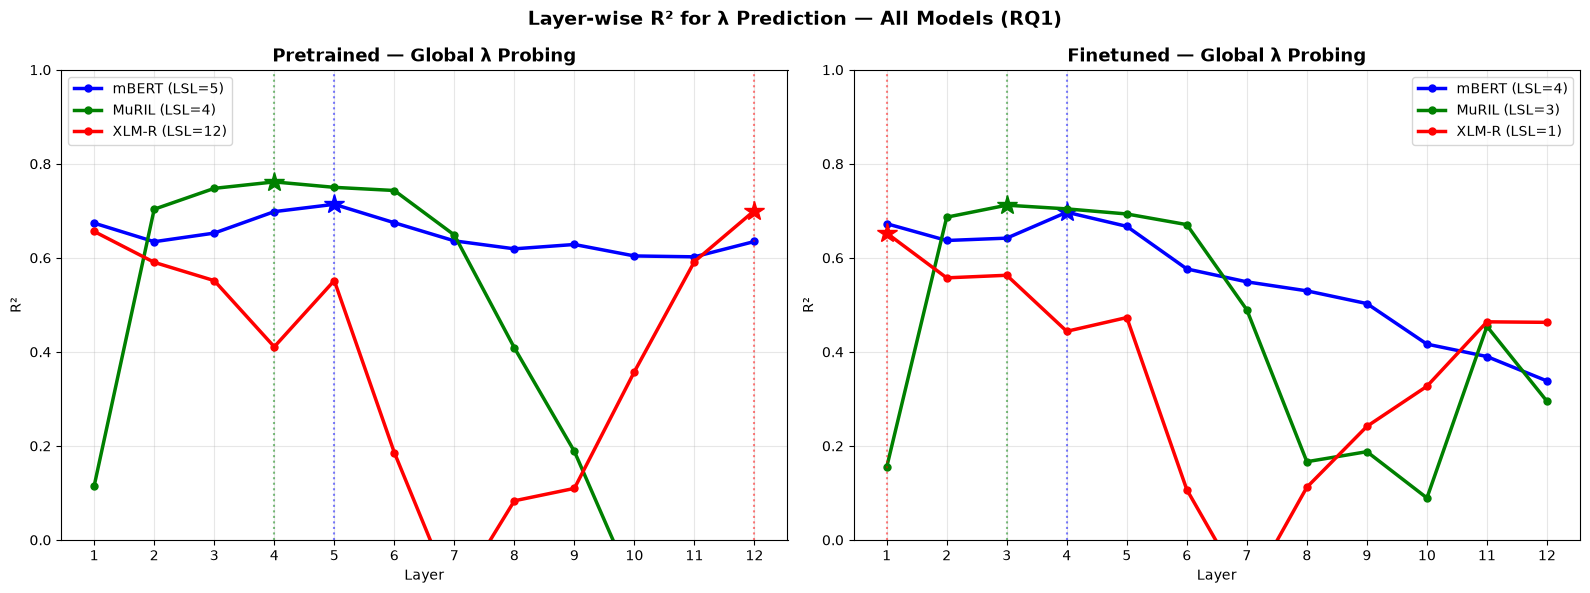

Saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

model_colors = {
    "bert-base-multilingual-cased": "blue",
    "muril-base-cased"            : "green",
    "xlm-roberta-base"            : "red"
}

for col, state in enumerate(states):
    ax = axes[col]

    for model in models:
        r        = phase7_results[(model, state)]
        r2_curve = r["r2_per_layer"]
        lsl      = r["LSL"]

        ax.plot(layers, r2_curve,
                label=f"{model_short[model]} (LSL={lsl})",
                color=model_colors[model],
                linewidth=2.5,
                marker="o",
                markersize=5)

        # Mark LSL with a vertical line
        ax.axvline(x=lsl,
                   color=model_colors[model],
                   linestyle=":",
                   alpha=0.5)

        # Mark peak R² with a star
        ax.plot(lsl, r2_curve[lsl-1],
                marker="*",
                color=model_colors[model],
                markersize=15)

    ax.set_title(f"{state.capitalize()} — Global λ Probing",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Layer")
    ax.set_ylabel("R²")
    ax.set_xticks(layers)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Layer-wise R² for λ Prediction — All Models (RQ1)",
             fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("//Users/harshaggarwal/Projects_4/hinemo_project/models/figures/global_r2_curves.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved.")